# ML Assignment 2 — Breast Cancer Wisconsin (Diagnostic) Classification

This notebook trains and evaluates 5 classification models on the same
dataset, as required by the assignment:

1. Logistic Regression
2. Decision Tree Classifier
3. K-Nearest Neighbor (kNN) Classifier
4. Gaussian Naive Bayes Classifier
5. Random Forest Classifier (Ensemble)

For each model we compute: **Accuracy, AUC, Precision, Recall, F1, MCC**.

**Dataset:** [UCI Breast Cancer Wisconsin (Diagnostic)](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) — 569 instances, 30 real-valued features, binary target (`diagnosis`: 1 = Malignant, 0 = Benign).


## 1. Load and Prepare Data

Attach the official WDBC attribute names to the raw file and encode the target.

In [1]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

RAW_PATH = os.path.join("..", "data_raw", "wdbc.data")
DATA_DIR = os.path.join("..", "data")
PROJECT_ROOT = ".."

BASE_FEATURES = [
    "radius", "texture", "perimeter", "area", "smoothness",
    "compactness", "concavity", "concave_points", "symmetry", "fractal_dimension",
]
COLUMNS = (
    ["id", "diagnosis"]
    + [f"{f}_mean" for f in BASE_FEATURES]
    + [f"{f}_se" for f in BASE_FEATURES]
    + [f"{f}_worst" for f in BASE_FEATURES]
)

df = pd.read_csv(RAW_PATH, header=None, names=COLUMNS)
df = df.drop(columns=["id"])
df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

print(df.shape)
df.head()


(569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [2]:
print("Class balance:")
print(df["diagnosis"].value_counts())
df.describe().T


Class balance:
diagnosis
0    357
1    212
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
diagnosis,569.0,0.372583,0.483918,0.000000,0.000000,0.000000,1.000000,1.00000
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave_points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400


## 2. Train / Test Split

80% train / 20% test, stratified on the target so both splits keep the same class balance.

In [3]:
os.makedirs(DATA_DIR, exist_ok=True)

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["diagnosis"]
)

train_df.to_csv(os.path.join(DATA_DIR, "train_data.csv"), index=False)
test_df.to_csv(os.path.join(PROJECT_ROOT, "test_data.csv"), index=False)

print("Train:", train_df.shape, " Test:", test_df.shape)


Train: (455, 31)  Test: (114, 31)


## 3. Feature Scaling

Logistic Regression (linear decision boundary on `w0 + wᵀx`, thresholded at 0.5)
and kNN (a lazy/instance-based learner using Euclidean distance) are both
scale-sensitive, so we standardize features (zero mean, unit variance) before
fitting any model. Tree-based models (Decision Tree, Random Forest) and
Gaussian Naive Bayes are unaffected by this scaling but are given the same
scaled input for a consistent, single preprocessing pipeline across all 5 models.


In [4]:
from sklearn.preprocessing import StandardScaler
import joblib

TARGET = "diagnosis"
X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]
X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

SAVED_DIR = "saved"
os.makedirs(SAVED_DIR, exist_ok=True)
joblib.dump(scaler, os.path.join(SAVED_DIR, "scaler.pkl"))
joblib.dump(list(X_train.columns), os.path.join(SAVED_DIR, "feature_names.pkl"))


['saved/feature_names.pkl']

## 4. Train the 5 Models

- **Logistic Regression** — linear model, sigmoid of `w0 + wᵀx`, decision threshold 0.5.
- **Decision Tree** — recursive partitioning (default Gini-index splits).
- **kNN** — lazy learning, majority vote among k = 5 nearest neighbors (Euclidean distance).
- **Gaussian Naive Bayes** — MAP rule under the class-conditional independence assumption, Gaussian likelihood per feature.
- **Random Forest (Ensemble)** — bagging: bootstrap-sampled rows + randomly sampled features per split, across 200 trees.


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "kNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Random Forest (Ensemble)": RandomForestClassifier(n_estimators=200, random_state=42),
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    filename = name.lower().replace(" ", "_").replace("(", "").replace(")", "") + ".pkl"
    joblib.dump(model, os.path.join(SAVED_DIR, filename))

print("Trained:", list(models.keys()))


Trained: ['Logistic Regression', 'Decision Tree', 'kNN', 'Naive Bayes', 'Random Forest (Ensemble)']


## 5. Evaluate Each Model

Metrics computed on the held-out test set: **Accuracy, AUC, Precision, Recall, F1, MCC**
(Matthews Correlation Coefficient).


In [6]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score,
    recall_score, f1_score, matthews_corrcoef,
)

def evaluate(model, X_test_scaled, y_test):
    y_pred = model.predict(X_test_scaled)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_score = model.decision_function(X_test_scaled)
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_score),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "MCC": matthews_corrcoef(y_test, y_pred),
    }

results = {name: evaluate(model, X_test_scaled, y_test) for name, model in models.items()}

results_df = pd.DataFrame(results).T
results_df.index.name = "ML Model Name"
results_df = results_df.round(4)
results_df


,Accuracy,AUC,Precision,Recall,F1,MCC
ML Model Name,,,,,,
Logistic Regression,0.9649,0.9960,0.9750,0.9286,0.9512,0.9245
Decision Tree,0.9298,0.9246,0.9048,0.9048,0.9048,0.8492
kNN,0.9561,0.9823,0.9744,0.9048,0.9383,0.9058
Naive Bayes,0.9211,0.9891,0.9231,0.8571,0.8889,0.8292
Random Forest (Ensemble),0.9649,0.9942,1.0000,0.9048,0.9500,0.9258


## 6. Comparison Table + Confusion Matrices

In [7]:
results_df.to_csv("metrics_summary.csv")
results_df


,Accuracy,AUC,Precision,Recall,F1,MCC
ML Model Name,,,,,,
Logistic Regression,0.9649,0.9960,0.9750,0.9286,0.9512,0.9245
Decision Tree,0.9298,0.9246,0.9048,0.9048,0.9048,0.8492
kNN,0.9561,0.9823,0.9744,0.9048,0.9383,0.9058
Naive Bayes,0.9211,0.9891,0.9231,0.8571,0.8889,0.8292
Random Forest (Ensemble),0.9649,0.9942,1.0000,0.9048,0.9500,0.9258


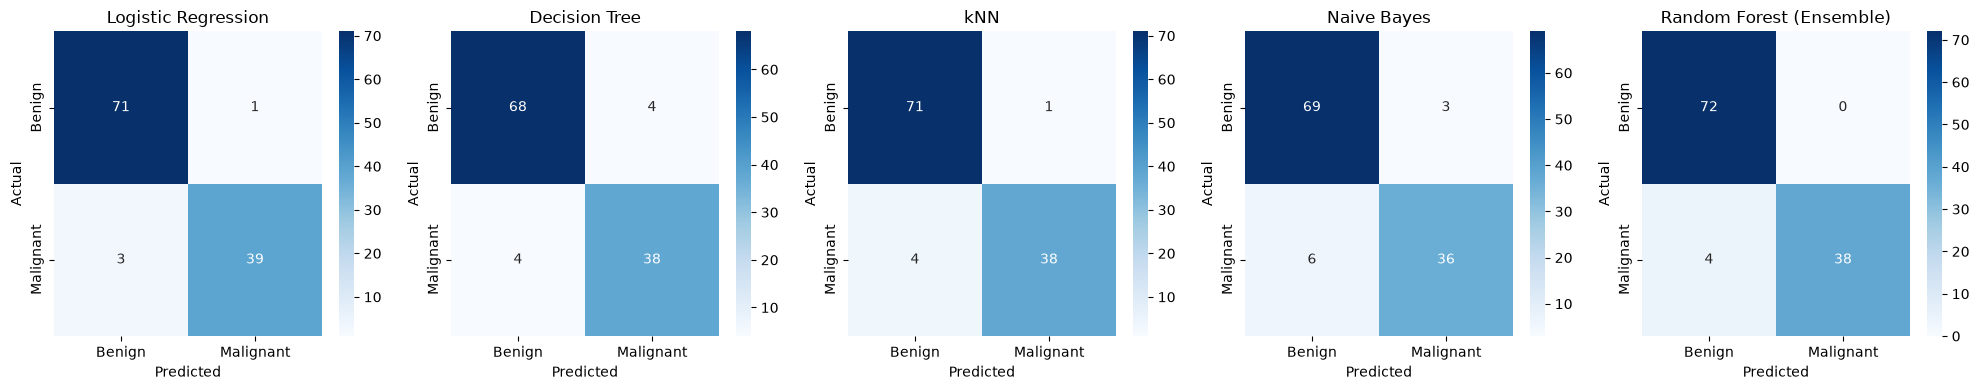

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


## 7. Observations

See `README.md` for the full comparison table and written observations per
model. Summary: Logistic Regression and Random Forest achieve the joint-best
accuracy; the single Decision Tree is the weakest model (overfits the small
training set); Naive Bayes trails on Recall/Accuracy since its class-conditional
independence assumption doesn't hold well for these highly correlated nuclear
features (e.g. `radius_mean`, `perimeter_mean`, `area_mean`).
